# 04. 피처 엔지니어링

IEEE-CIS는 **모델보다 피처가 중요한** 데이터다. 효과 순서대로:

1. **카드 소유자 추정** — 가장 큰 이득. 목적 진술의 '이용자 맥락'이 이 부분
2. 빈도 인코딩 — 고카디널리티 범주형
3. 금액 파생 — 소수부, 과거 대비 비율
4. 집계 피처 — 소유자/기기/도메인별 통계

> **누수 주의**: 집계를 전체 데이터에서 계산하면 미래 정보가 들어간다.
> 학습 행은 각 거래 직전까지의 이력으로 집계하고, 이후 구간에는
> train 구간에서 고정한 통계를 적용한다.

산출물: `data/processed/features.parquet`

In [1]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from frauddetectionreport import config, data, splits, features

# 장시간 열린 Jupyter 커널이 수정 전 모듈을 캐시하지 않도록 다시 읽는다.
import importlib
features = importlib.reload(features)
from frauddetectionreport.config import TARGET, TIME_COL, AMOUNT_COL

train = data.load("train")
sp = splits.make_time_split(train)
print(f"features 모듈: {features.__file__}")
print(train.shape)
display(sp.summary(train))

features 모듈: C:\fraudDetectionReport\src\frauddetectionreport\features.py
(590540, 434)


,split,n,days,fraud_rate
0,train,383851,110.280521,0.034196
1,calib,88581,29.839352,0.039207
2,test,118108,41.877674,0.034409


## 1. 카드 소유자 추정 ← 핵심

고객 ID가 없다. `D1`은 카드·계정·이메일·IP 등 어떤 개체와 관련된
시간차인지 공개되지 않았다. 다만 거래일에서 빼 얻은 기준일과 카드·주소를
결합하면 동일 이용자를 근사하는 데 유용하다는 경쟁 사례가 있어 휴리스틱으로 사용한다.

$$\\text{account\\_day} = \\lfloor \\text{TransactionDT}/86400 \\rfloor - D_1$$

여기에 `card1`(카드 식별자)과 `addr1`(청구 주소)을 결합해 `uid` 를 만든다.

> **결측 처리**: `D1`, `card1`, `addr1` 중 하나라도 없으면 소유자를 추정할 수 없다.
> 이때 결측을 하나의 값으로 묶으면 서로 무관한 거래들이 한 소유자가 되어
> 집계 피처가 오염되므로, **거래마다 고유 키를 주어 분리**한다.
> `uid_is_estimated` 가 추정 성공 여부를 표시한다.


In [2]:
train = features.add_uid(train)
assert "uid_is_estimated" in train.columns, (
    f"현재 로드된 {features.__file__}의 add_uid()가 uid_is_estimated를 만들지 않았습니다. "
    "커널을 재시작하고 첫 셀부터 실행하세요."
)

sizes = train.groupby(features.UID_COL, observed=True).size()
est_rate = train["uid_is_estimated"].mean()

print(f"추정 소유자 수 : {train[features.UID_COL].nunique():,}  (거래 {len(train):,}건)")
print(f"추정 성공률    : {est_rate:.1%}  (D1·card1 결측이면 추정 불가)")
print(f"소유자당 거래 수 — 중앙값 {sizes.median():.0f}, 평균 {sizes.mean():.2f}, 최대 {sizes.max():,}")
print(f"1회성 소유자 비중: {(sizes == 1).mean():.1%}")

# 추정 성공한 거래만으로 다시 본다 (결측 거래는 정의상 모두 1회성이라 지표를 왜곡)
est = train[train.uid_is_estimated == 1]
sizes_est = est.groupby(features.UID_COL, observed=True).size()
print(f"\n[추정 성공분만] 소유자 {sizes_est.size:,}명, 거래 {len(est):,}건")
print(f"  소유자당 중앙값 {sizes_est.median():.0f}, 평균 {sizes_est.mean():.2f}")
print(f"  1회성 비중 {(sizes_est == 1).mean():.1%}")


추정 소유자 수 : 265,864  (거래 590,540건)
추정 성공률    : 88.7%  (D1·card1 결측이면 추정 불가)
소유자당 거래 수 — 중앙값 1, 평균 2.22, 최대 1,414
1회성 소유자 비중: 68.6%

[추정 성공분만] 소유자 199,070명, 거래 523,746건
  소유자당 중앙값 1, 평균 2.63
  1회성 비중 58.0%


### 추정이 타당한지 점검

**소유자 추정이 실패했는지 여기서 판별한다.** 두 가지를 본다.

**(a) 묶임이 실제로 일어났는가** — 거의 모든 거래가 서로 다른 uid를 받았다면
(1회성 비중이 90%를 넘는다면) 키가 너무 세밀한 것이다. `addr1`을 빼거나
`card1`만 쓰는 식으로 키를 완화해야 한다.

**(b) 사기가 소유자 단위로 뭉쳐 있는가** — 대회 라벨 정의상 사기 카드의
이후 거래도 사기로 표시되므로, uid가 실제 소유자를 잡고 있다면 사기가
소유자 단위로 일관되게 나타나야 한다. 무작위로 흩어져 있다면 uid는 잡음이다.


(a) 1회성 소유자 비중: 58.0%  OK

(b) 2건 이상 소유자 83,557명
    사기/정상이 일관된 비율 : 98.5%
    무작위였을 때 기댓값     : 89.3%
    → uid가 실제 소유자를 잡고 있다


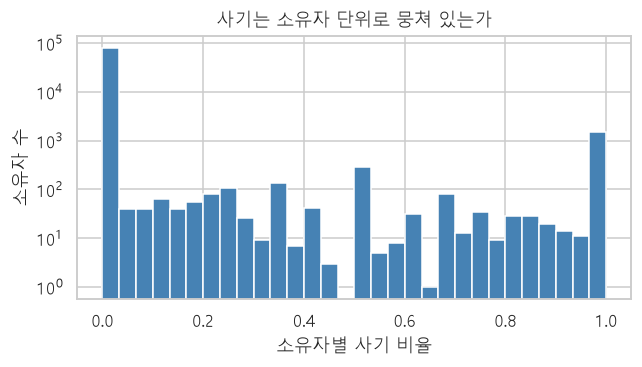

In [3]:
uid_fraud = est.groupby(features.UID_COL, observed=True)[TARGET].agg(["size", "mean"])
multi = uid_fraud[uid_fraud["size"] >= 2]

one_off = (uid_fraud["size"] == 1).mean()
print(f"(a) 1회성 소유자 비중: {one_off:.1%}", end="  ")
print("← 90% 넘으면 키가 너무 세밀함 (addr1 제외 검토)" if one_off > 0.9 else "OK")

if len(multi) == 0:
    print("\n2건 이상 소유자가 없어 (b) 점검 불가 — 키 재설계 필요")
else:
    pure = ((multi["mean"] == 0) | (multi["mean"] == 1)).mean()
    # 같은 크기 그룹을 무작위로 만들었을 때의 기댓값과 비교해야 의미가 있다
    fr = est[TARGET].mean()
    exp_pure = ((1 - fr) ** multi["size"] + fr ** multi["size"]).mean()
    print(f"\n(b) 2건 이상 소유자 {len(multi):,}명")
    print(f"    사기/정상이 일관된 비율 : {pure:.1%}")
    print(f"    무작위였을 때 기댓값     : {exp_pure:.1%}")
    print(f"    → {'uid가 실제 소유자를 잡고 있다' if pure > exp_pure + 0.02 else '무작위와 구분되지 않음 — 키 재설계 필요'}")

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(multi["mean"], bins=30, color="steelblue")
    ax.set_xlabel("소유자별 사기 비율"); ax.set_ylabel("소유자 수"); ax.set_yscale("log")
    ax.set_title("사기는 소유자 단위로 뭉쳐 있는가")
    plt.tight_layout(); plt.show()


> **한계**: uid는 추정이며 검증할 정답이 없다. 서로 다른 사람이 같은 키를
> 가질 수도, 같은 사람이 카드를 바꿔 분리될 수도 있다. 보고서에 명시한다.

## 2. 시점 기준 누적 피처

각 거래 시점까지의 정보만 사용하므로 누수가 없다.
실무의 스트리밍 피처("지난 N건의 평균")를 오프라인에서 근사한 것이다.

In [4]:
%%time
train = features.add_expanding_uid_features(train)

cols = ["uid_txn_seq", "uid_secs_since", "uid_amt_cummean", "uid_amt_vs_hist"]
display(train[cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
uid_txn_seq,590540.0,5.399976,4.122528e+01,0.000000,0.000000,1.000000,4.000000e+00,1.413000e+03
uid_secs_since,324676.0,946813.875000,1.610571e+06,0.000000,7491.750000,264415.500000,1.209192e+06,1.547974e+07
uid_amt_cummean,324676.0,138.324295,2.056985e+02,0.424000,56.500000,89.751228,1.459737e+02,2.176572e+04
uid_amt_vs_hist,324676.0,1.231899,2.063925e+00,0.005539,0.644628,0.993371,1.243178e+00,2.039967e+02


CPU times: total: 1.84 s
Wall time: 1.88 s


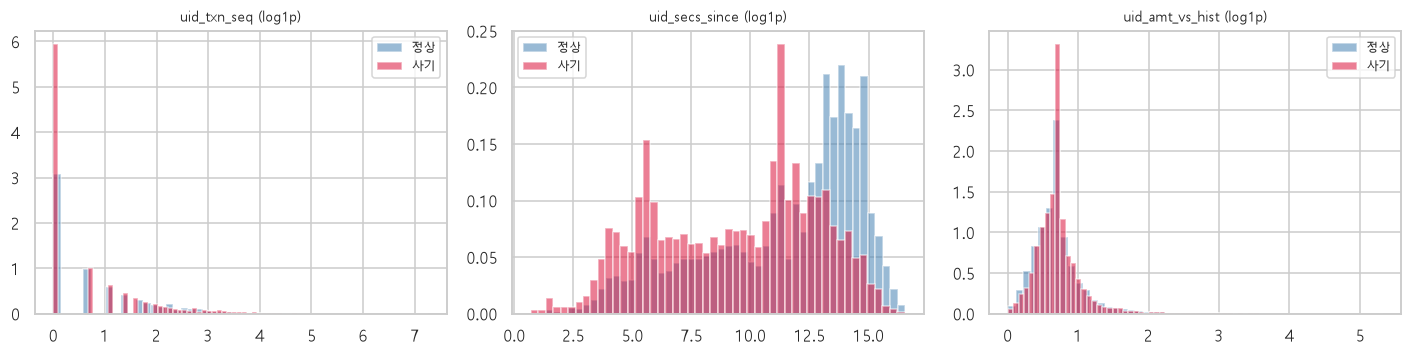

In [5]:
# 이 피처들이 실제로 사기를 구분하는지
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, ["uid_txn_seq", "uid_secs_since", "uid_amt_vs_hist"]):
    for label, name, c in [(0, "정상", "steelblue"), (1, "사기", "crimson")]:
        s = train.loc[train[TARGET] == label, col].dropna()
        s = s[s > 0] if col != "uid_txn_seq" else s
        ax.hist(np.log1p(s), bins=50, density=True, alpha=0.55, label=name, color=c)
    ax.set_title(f"{col} (log1p)", fontsize=9); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. 전체 파이프라인 실행

`build_features()` 가 uid 생성 → 누적 피처 → 빈도 인코딩 → 집계를 수행한다.
**통계는 train 구간에서만 fit** 한다.

In [6]:
%%time
train_raw = data.load("train")
feat, fb = features.build_features(train_raw, fit_mask=sp.train)

new_cols = [c for c in feat.columns if c not in train_raw.columns]
print(f"{feat.shape[1] - train_raw.shape[1]}개 피처 추가 → 총 {feat.shape[1]}개")
print(new_cols)

34개 피처 추가 → 총 468개
['uid', 'uid_is_estimated', 'uid_txn_seq', 'uid_secs_since', 'uid_amt_cummean', 'uid_amt_vs_hist', 'hour', 'dayofweek', 'day', 'amt_log', 'amt_decimal', 'amt_is_round', 'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'DeviceInfo_freq', 'uid_freq', 'uid_amt_mean', 'uid_amt_std', 'uid_count', 'uid_amt_ratio', 'card1_amt_mean', 'card1_amt_std', 'card1_count', 'card1_amt_ratio', 'DeviceInfo_amt_mean', 'DeviceInfo_amt_std', 'DeviceInfo_count', 'DeviceInfo_amt_ratio']
CPU times: total: 38.3 s
Wall time: 26.7 s


### 금액 소수부 — 알려진 강한 신호

정수 금액(100.00)과 환율 변환을 거친 금액(117.43)은 성격이 다르다.

In [7]:
g = feat.groupby("amt_is_round", observed=True)[TARGET].agg(["size", "mean"])
g.index = ["소수부 있음", "정수 금액"]
g.columns = ["건수", "사기율"]
display(g.style.format({"건수": "{:,}", "사기율": "{:.3%}"}))

,건수,사기율
소수부 있음,"285,527",3.426%
정수 금액,"305,013",3.568%


## 4. 저장

이후 05 노트북이 읽는다.

In [8]:
%%time
config.ensure_dirs()
feat.to_parquet(config.FEATURES_PARQUET, index=False)
print(f"저장: {config.FEATURES_PARQUET}")
print(f"      {config.FEATURES_PARQUET.stat().st_size / 1e6:.1f} MB, {feat.shape}")

저장: C:\fraudDetectionReport\data\processed\features.parquet
      121.8 MB, (590540, 468)
CPU times: total: 17.1 s
Wall time: 15.1 s


## 요약

- `uid` 로 카드 소유자 추정 → 목적 진술의 '이용자 맥락' 확보
- 시점 기준 누적 피처로 '행동 맥락' 근사 (누수 없음)
- 빈도 인코딩·집계는 train 구간에서만 fit
- 다음: `05_model` — 확률 추정과 **캘리브레이션**